This notebook contains an initial experiment about the capacitance and gleak values. I wanted to see if the first ramp up of the multicompartment simulation with the original capacitance and gleak values can be matched by fixing the capacitance to 1.0 but changing the gleak. We can say that the ramp cannot be matched well, because it depends on the other 25 parameters, and the gleak value cannot change the ramp really flexibly.

You can change the random seed and the gleak values to get nice experiments and plots!

In [ ]:
%load_ext autoreload
%autoreload 2

import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

from jax import config
config.update("jax_enable_x64", True)



import importlib
import voltage_fitting.build_simulator
importlib.reload(voltage_fitting.build_simulator)

import matplotlib.pyplot as plt
import jax


In [2]:
from voltage_fitting.build_simulator import (
    get_bounds,
    get_prior,
    build_cell,
    set_setup,
    transform_uniform_to_normal,
    get_experimental_data,
    setup_simulator
)

dt=0.025

In [18]:
t_max = 110.0
cut = 0


setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"
all_setup = set_setup(setup)
cell = build_cell(all_setup["swc_fname"], all_setup["rotation"],  all_setup["capacitance"], all_setup["eleak"], all_setup["gleak"])
t, x_o, i_amp = get_experimental_data(setup, cut, t_max)
simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)

_, lower, upper = get_bounds()
transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)
rng_key = jax.random.PRNGKey(0)
init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initializations randomly.
opt_params = sample_prior(init_rng_key)

@jax.jit
def predict(params):
    params_0 = inv_transform_params(params)
    return simulate(params_0)[0]

v_o = predict(opt_params)
v_list = []
diffs = []

gleaks = [1.5, 1.8, 2.0, 2.2, 2.5, 3.0, 3.5, 5.0] #Change the values for different cells

def predict(params):
        params_0 = inv_transform_params(params)
        return simulate(params_0)[0]

for i in gleaks:
    cell = build_cell(all_setup["swc_fname"], all_setup["rotation"],  1.0, all_setup["eleak"], i*1e-4)
    print("Cap: ", 1.0, "E_Leak: ", all_setup["eleak"], "g_Leak: ", i*1e-4)
    simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)

    
    v = predict(opt_params)
    diffs.append(sum(abs(v[:2800]-v_o[:2800])))  #Change the range for different cells
    v_list.append(v)


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


dt_difference 5.0
Amplitude stimulus: 0.20999999344348907
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 25


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Cap:  1.0 E_Leak:  -88.0 g_Leak:  0.00015000000000000001
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


...

Cap:  1.0 E_Leak:  -88.0 g_Leak:  0.00030000000000000003
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Cap:  1.0 E_Leak:  -88.0 g_Leak:  0.00035
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Cap:  1.0 E_Leak:  -88.0 g_Leak:  0.0005
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


You can see based on these plots how changing the gleak changes the beginning of the trace, but the ramp won't really match with the v_o.

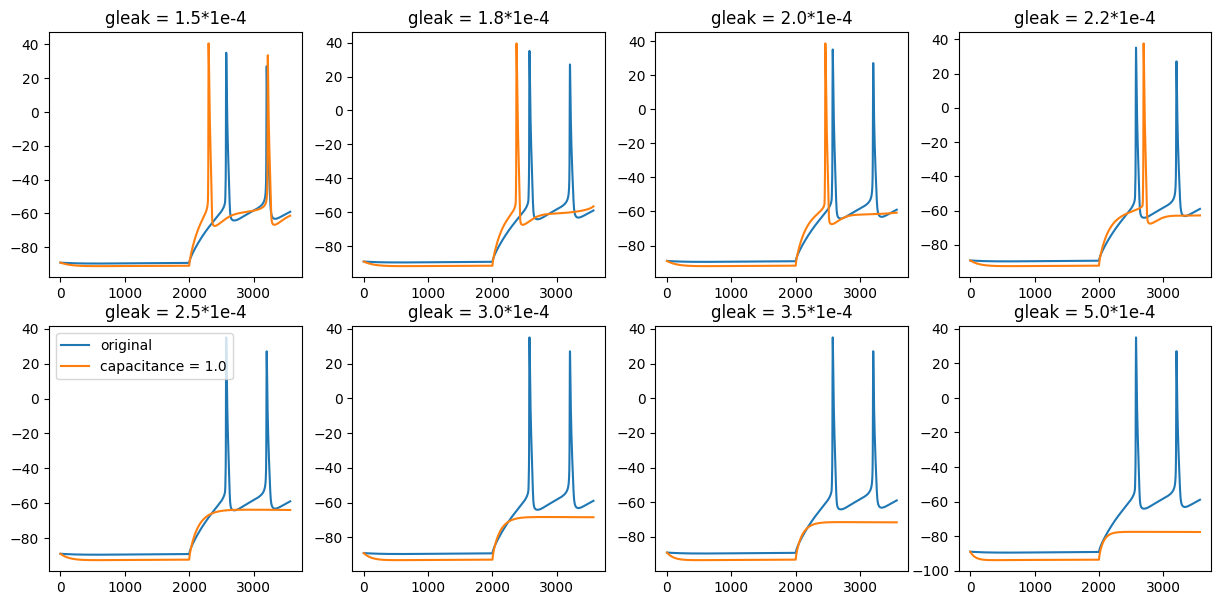

In [29]:
#"79", rm:0
fig, axs = plt.subplots(2,4,figsize=(15,7))
for i in range(2):
    for j in range(4):
        axs[i][j].plot(v_o[:3570], label = 'original')
        axs[i][j].plot(v_list[4*i + j][:3570], label = 'capacitance = 1.0')
        axs[i][j].set_title(f'gleak = {gleaks[4*i+j]}*1e-4')
axs[1][0].legend()

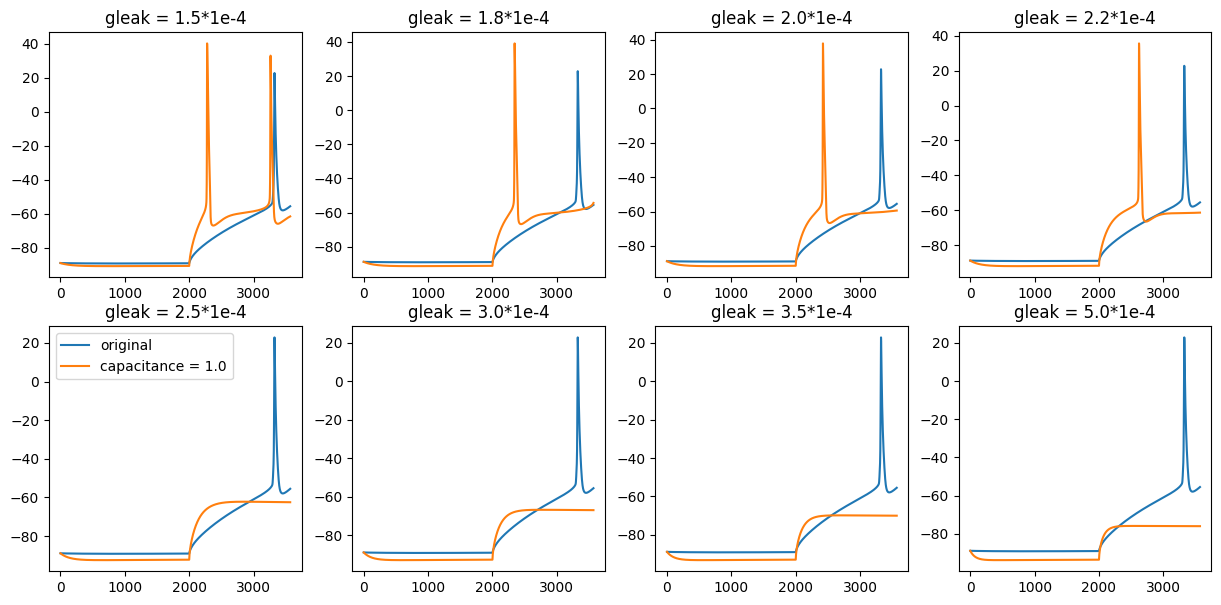

In [11]:
#"86" rm:0
fig, axs = plt.subplots(2,4,figsize=(15,7))
for i in range(2):
    for j in range(4):
        axs[i][j].plot(v_o[:3570], label = 'original')
        axs[i][j].plot(v_list[4*i + j][:3570], label = 'capacitance = 1.0')
        axs[i][j].set_title(f'gleak = {gleaks[4*i+j]}*1e-4')
axs[1][0].legend()

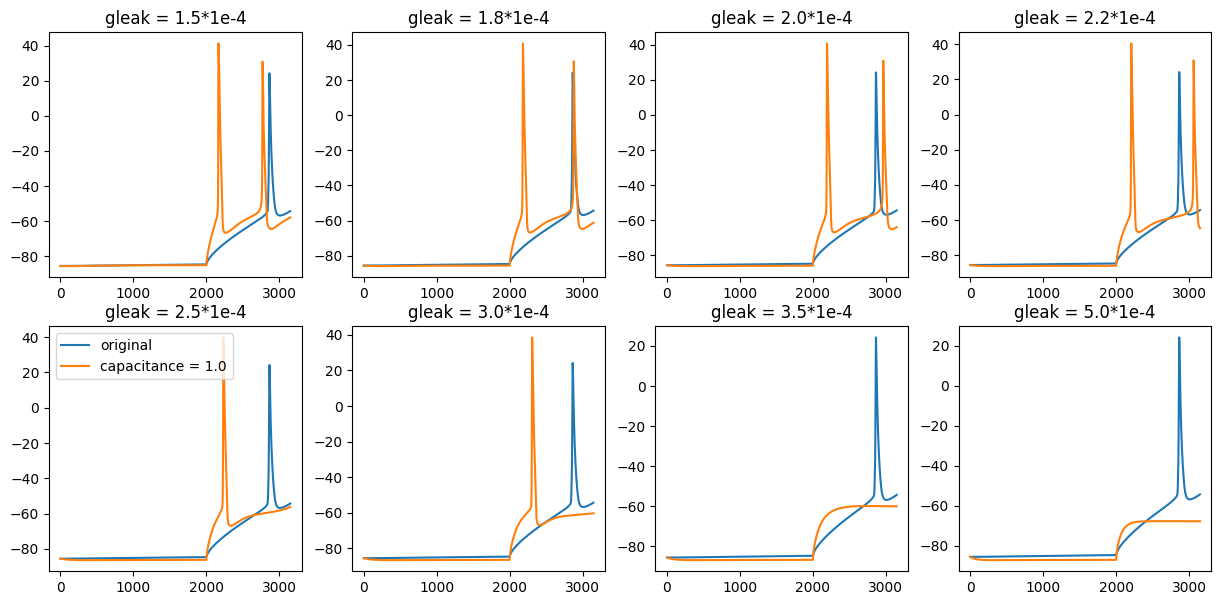

In [15]:
#"32"
fig, axs = plt.subplots(2,4,figsize=(15,7))
for i in range(2):
    for j in range(4):
        axs[i][j].plot(v_o[:3150], label = 'original')
        axs[i][j].plot(v_list[4*i + j][:3150], label = 'capacitance = 1.0')
        axs[i][j].set_title(f'gleak = {gleaks[4*i+j]}*1e-4')
axs[1][0].legend()

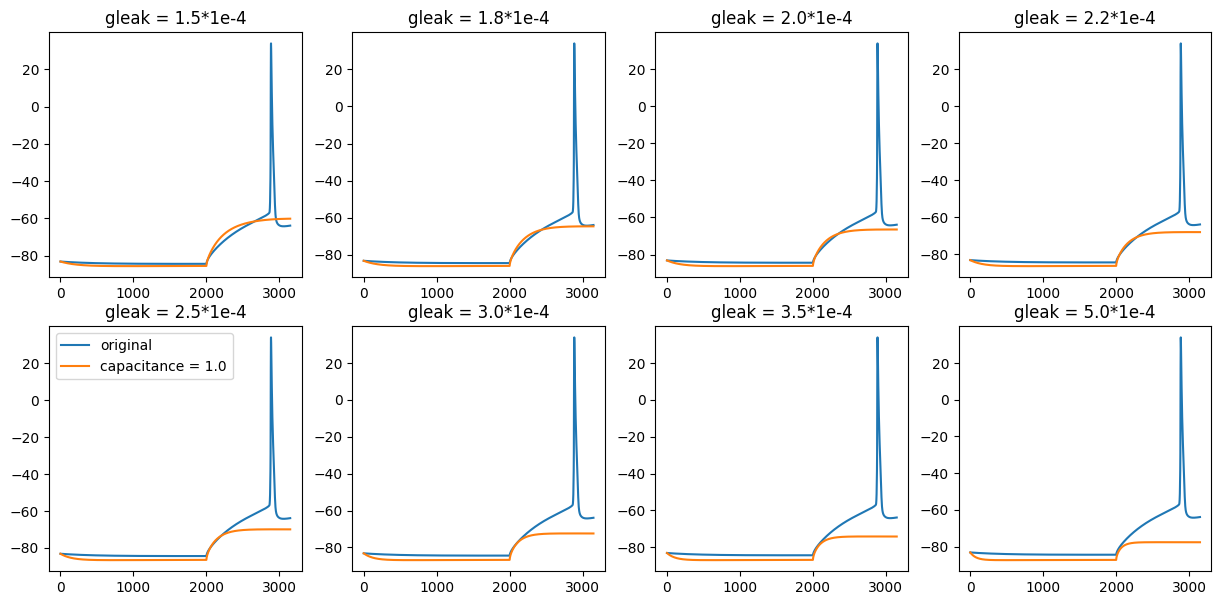

In [19]:
#"25"
fig, axs = plt.subplots(2,4,figsize=(15,7))
for i in range(2):
    for j in range(4):
        axs[i][j].plot(v_o[:3150], label = 'original')
        axs[i][j].plot(v_list[4*i + j][:3150], label = 'capacitance = 1.0')
        axs[i][j].set_title(f'gleak = {gleaks[4*i+j]}*1e-4')
axs[1][0].legend()